In [1]:
import numpy as np
import sys, os, re, math
import torch
from model import GCN
from tqdm import tqdm
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

In [2]:
ds_dir = "../datasets"
gnns_dir = "../gnns"
version = "v4"
proteomeid_dict = {"HUMAN" : "UP000005640_9606",
                   "MOUSE" : "UP000000589_10090",
                   "RAT" : "UP000002494_10116",
                   "YEAST" : "UP000002311_559292"
                  }
annotation = "binding"


In [3]:
#models
model_8_seq_struc_dict = {
    'model_name' : "Sequence & structure",
    'model_path' : gnns_dir + "/model_cutoff8_1282",
    'inp_node_features' : [1282],
    'hidden_neurons' : [297],
    'dropout_rates' : [0.439],
    'thresholds' : {"HUMAN": 0.5, #best thresholds for human, mouse, rat, yeast 
                    "MOUSE": 0.5, 
                    "RAT": 0.5, 
                    "YEAST": 0.5}, 
    'graph_type' : "cutoff8_phipsi_esm2embeddings",
    'color' : "#00441b"
}
        
model_8_seq_dict = {
    'model_name' : "Sequence",
    'model_path' : gnns_dir + "/model_cutoff8_1280_nohpo",
    'inp_node_features' : [1280],
    'hidden_neurons' : [297],
    'dropout_rates' : [0.439],
    'thresholds' : {"HUMAN": 0.5, 
                    "MOUSE": 0.5, 
                    "RAT": 0.5, 
                    "YEAST": 0.5},
    'graph_type' : "cutoff8_esm2embeddings",
    'color' : "#ff00ff"
}

model_8_struc_dict = {
    'model_name' : "Structure",
    'model_path' : gnns_dir + "/model_cutoff8_2_nohpo",
    'inp_node_features' : [2],
    'hidden_neurons' : [297],
    'dropout_rates' : [0.439],
    'thresholds' : {"HUMAN": 0.5, 
                    "MOUSE": 0.5, 
                    "RAT": 0.5, 
                    "YEAST": 0.5},
    'graph_type' : "cutoff8_phipsi",
    'color' :"#00bfff"
}

#compare_models = "Sequence & structure vs. Sequence"
#compare_models = "Sequence & structure vs. Structure"
compare_models = "Sequence vs. Structure"

if compare_models == "Sequence & structure vs. Sequence":
    model1_dict = model_8_seq_dict
    model2_dict = model_8_seq_struc_dict
elif compare_models == "Sequence & structure vs. Structure":
    model1_dict = model_8_seq_struc_dict
    model2_dict = model_8_struc_dict
elif compare_models == "Sequence vs. Structure":
    model1_dict = model_8_seq_dict
    model2_dict = model_8_struc_dict


In [4]:
#define the models
out_labels = 1
neurons_m1 = model1_dict['inp_node_features'] + model1_dict['hidden_neurons'] + [out_labels] #neurons in each layer
neurons_m2 = model2_dict['inp_node_features'] + model2_dict['hidden_neurons'] + [out_labels] 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model1 = GCN(neurons_m1).to(device)
model2 = GCN(neurons_m2).to(device)

#load models
model1.load_state_dict(torch.load(model1_dict['model_path']))
model2.load_state_dict(torch.load(model2_dict['model_path']))


<All keys matched successfully>

In [5]:
#predict annotations and compute tp and fp
#save the corresponding tp and fp into a dictionary
tp_dict = {} #key = organism; value = [tp_model1, tp_model2, tp_model1 & model2]
fp_dict = {} #key = organism; value = [fp_model1, fp_model2, fp_model1 & model2]

#initialize the dictionary
for organism in proteomeid_dict.keys():
    tp_dict[organism] = [0, 0, 0]
    fp_dict[organism] = [0, 0, 0]

def predict (data, model, dropout_rates, threshold):
    model.eval()
    with torch.no_grad():
        pred = model(data, dropout_rates)
    sites = np.argwhere(pred.t()[0,:] >= threshold) #0-based
    if (sites.nelement() != 0):
        pred_list = [int(site) for site in np.nditer(sites)]
    else:
        pred_list = []
    return (sorted(pred_list))

for organism, proteomeid in proteomeid_dict.items():


    #load the datasets
    graphs1 = ds_dir + "/" + proteomeid + "_" + organism + "_" + version + "_" + annotation + "_" + model1_dict['graph_type'] + ".pt"
    graphs2 = ds_dir + "/" + proteomeid + "_" + organism + "_" + version + "_" + annotation + "_" + model2_dict['graph_type'] + ".pt"
    dataset1 = torch.load(graphs1)
    dataset2 = torch.load(graphs2)

    total_actual = 0
    total_ids = len(dataset1)
    pbar = tqdm(zip(dataset1, dataset2), total = total_ids)
    for i, (data1, data2) in enumerate(pbar):
        uniprotid = data1.uniprotid
        pbar.set_description("Predicting {:6n}/{:6n} UniProtID {:12s}".format(i+1, total_ids, uniprotid))

        pred_data1 = predict(data1, model1, model1_dict['dropout_rates'], model1_dict['thresholds'][organism])
        pred_data2 = predict(data2, model2, model2_dict['dropout_rates'], model2_dict['thresholds'][organism])
    
        actual1 = sorted(list(np.where(np.array(data1.y)==1)[0]))
        actual2 = sorted(list(np.where(np.array(data2.y)==1)[0]))
        if actual1 == actual2:
            actual = actual1
            total_actual = total_actual + len(actual)
            
            tp1 = list(set(actual) & set(pred_data1))
            tp2 = list(set(actual) & set(pred_data2))
            tp1and2 = list(set(tp1) & set(tp2))
            
            fp1 = list(set(pred_data1) - set(actual))
            fp2 = list(set(pred_data2) - set(actual))
            fp1and2 = list(set(fp1) & set(fp2))
            
            tp_dict[organism][0] = tp_dict[organism][0] + len(tp1) - len(tp1and2)
            tp_dict[organism][1] = tp_dict[organism][1] + len(tp2) - len(tp1and2)
            tp_dict[organism][2] = tp_dict[organism][2] + len(tp1and2)
            
            fp_dict[organism][0] = fp_dict[organism][0] + len(fp1) - len(fp1and2)
            fp_dict[organism][1] = fp_dict[organism][1] + len(fp2) - len(fp1and2)
            fp_dict[organism][2] = fp_dict[organism][2] + len(fp1and2)
            
        else:
            print("ERROR: Annotation of the two graphs is different: UniProtID {}".format(uniprotid))
            break

    print("Total binding site residues for {} = {}".format(organism, total_actual))
    del dataset1
    del dataset2
del model1
del model2

Predicting   5994/  5994 UniProtID F8WAB6      : 100%|█| 5994/5994 [00:28<0


Total binding site residues for HUMAN = 57439


Predicting   5223/  5223 UniProtID Q3UTL8      : 100%|█| 5223/5223 [00:27<0


Total binding site residues for MOUSE = 50150


Predicting   2177/  2177 UniProtID A0A0G2K6M9  : 100%|█| 2177/2177 [00:13<0


Total binding site residues for RAT = 20274


Predicting   1362/  1362 UniProtID P39567      : 100%|█| 1362/1362 [00:08<0


Total binding site residues for YEAST = 15233


Text(-0.576108759963015, -3.210916071176408e-17, '1941')
Text(0.026899827186510572, 0.0, '1103281')
Text(-0.5367956608952702, 3.4516393758657897e-17, '3442')
Text(-0.5793299366231486, -3.119440377341903e-17, '3343')
Text(0.037691011090902504, 0.0, '976806')
Text(-0.5255411000180865, 3.448802010233149e-17, '5617')
Text(-0.5823115412004121, -3.0357516826830235e-17, '2240')
Text(0.0471408707446303, 0.0, '396013')
Text(-0.5154732719617012, 3.445018045101705e-17, '3397')
Text(-0.5769188879388756, -3.098210670542293e-17, '874')
Text(0.04371843802966677, 0.0, '276609')
Text(-0.519588325090855, 3.4492591219680164e-17, '2012')


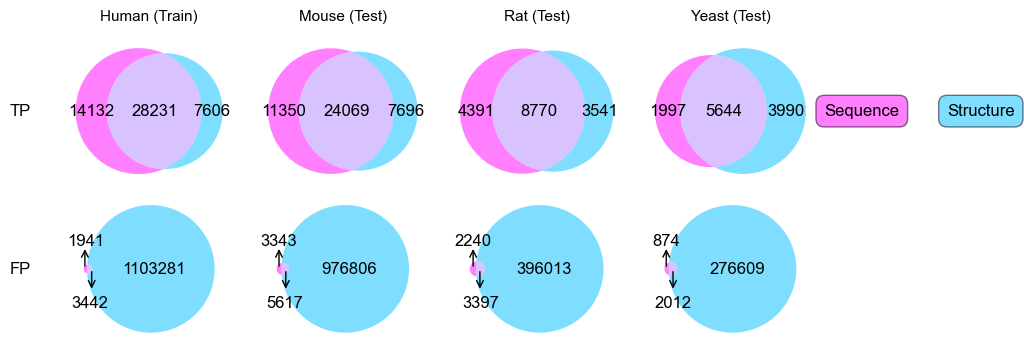

In [6]:
#Venn2 plot
mpl.rcParams['font.sans-serif'] = "Arial"
plt.rcParams.update({'font.size': 12})
fig, axes = plt.subplots(nrows=2, ncols=len(proteomeid_dict.keys()), figsize=(10,4))
plt.subplots_adjust(wspace=0, hspace=0.05)

for y, organism in enumerate(proteomeid_dict.keys()): #column
    
    venn2(subsets = (tp_dict[organism][0], tp_dict[organism][1], tp_dict[organism][2]), set_labels = ('', ''), set_colors=(model1_dict['color'], model2_dict['color']), alpha=0.5, ax = axes[0][y])
    v2 = venn2(subsets = (fp_dict[organism][0], fp_dict[organism][1], fp_dict[organism][2]), set_labels = ('', ''), set_colors=(model1_dict['color'], model2_dict['color']), alpha=0.5, ax = axes[1][y])
    
    ########################
    for i, text in enumerate(v2.subset_labels):
        print (text)
        if i == 0:
            axes[1][y].annotate("", xytext=(-0.58, 0), xy=(-0.58, 0.2), arrowprops=dict(arrowstyle="->"))
            text.set_y(0.25)
        elif i == 2:
            axes[1][y].annotate("", xytext=(-0.52, 0), xy=(-0.52, -0.2), arrowprops=dict(arrowstyle="->"))
            text.set_y(-0.3)
    ########################
        
    if organism == 'HUMAN':
        title = organism.title() + " (Train)"
    else:
        title = organism.title() + " (Test)"
    axes[0][y].set_title(title, y=1.05, fontsize=11)
    
    if y == 0:
        axes[0][y].text(-0.25, 0.5, 'TP', horizontalalignment='center', verticalalignment='center', transform=axes[0][y].transAxes)
        axes[1][y].text(-0.25, -0.55, 'FP', horizontalalignment='center', verticalalignment='center', transform=axes[0][y].transAxes)
    elif y == 3:
        axes[0][y].text(1.35, 1.55, model1_dict['model_name'],
            horizontalalignment='center',
            verticalalignment='center',
            transform=axes[1][y].transAxes, # Places text relative to axes, not data
            bbox=dict(facecolor=model1_dict['color'], alpha=0.5, edgecolor='black', linewidth=1, boxstyle='round,pad=0.5'))
        axes[0][y].text(2.12, 1.55, model2_dict['model_name'],
            horizontalalignment='center',
            verticalalignment='center',
            transform=axes[1][y].transAxes, # Places text relative to axes, not data
            bbox=dict(facecolor=model2_dict['color'], alpha=0.5, edgecolor='black', linewidth=1, boxstyle='round,pad=0.5'))
        
plt.show()
    